# All-to-All Distance Slow-Mode Pipeline

One end-to-end notebook for generating all-pair keypoint-distance data, tuning one species, running single-species or multispecies batches, and comparing species through slow-mode basin projections, transfer dynamics, and MoSeq syllable identities.

Heavy stages are controlled by explicit `RUN_*` flags. Saved projections and batch outputs can be resumed without recomputing earlier stages.

## 1. Configuration

In [3]:
import importlib
import pooled_user_pipeline as pup
import fly_plot_recreation as fpr

pup = importlib.reload(pup)
fpr = importlib.reload(fpr)

In [2]:
from pathlib import Path
import gc
import importlib
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Make local project modules importable even when this notebook is in a subfolder.
REPO_ROOT = Path('/Users/meganbishop/slowmodeevo')
if not (REPO_ROOT / 'pooled_user_pipeline.py').exists():
    candidates = [Path.cwd(), *Path.cwd().parents]
    REPO_ROOT = next(
        (path for path in candidates if (path / 'pooled_user_pipeline.py').exists()),
        REPO_ROOT,
    )
if not (REPO_ROOT / 'pooled_user_pipeline.py').exists():
    raise FileNotFoundError(f'Could not locate pooled_user_pipeline.py under {REPO_ROOT}')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pipeline as pp
import pooled_user_pipeline as pup
import figures as fg
import gpcca_utils as gu
import all_pair_distance_data as apd
import multi_species_comparison as msc

pp = importlib.reload(pp)
pup = importlib.reload(pup)
fg = importlib.reload(fg)
gu = importlib.reload(gu)
apd = importlib.reload(apd)
msc = importlib.reload(msc)
fg.setup_style()

DATAVERSE_ROOT = Path('/Users/meganbishop/moseq_dataverse')


# Reuse the existing saved all-to-all distance runs.
OUTPUT_ROOT = REPO_ROOT / 'outputs' / 'single_species_distance_comparison'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

REPRESENTATIONS = {
    'egocentered_and_normalized_distances': 'recording/egocentric_coordinates_rigid',
    'normalized_distances': 'recording/size_normalized_gimbal_keypoints',
}
TUNING_REPRESENTATION = 'egocentered_and_normalized_distances'
TUNING_SPECIES = 'Mus_musculus'
REFERENCE_SPECIES = 'Peromyscus_polionotus'
BATCH_SPECIES = [
    'Mus_caroli', 'Mus_musculus', 'Mus_spretus',
    'Peromyscus_californicus', 'Peromyscus_gossypinus',
    'Peromyscus_leucopus', 'Peromyscus_maniculatus',
    'Peromyscus_polionotus',
]

# Shared data/pipeline settings.
STRIDE = 1
MAX_FRAMES_PER_RECORDING = None
FMIN = 0.5
FMAX_CAP = 60.0
N_FREQS = 25
WAVELET_SUBSAMPLE_FACTOR = 50
NORMALIZE_WAVELETS_FOR_PCA = True
KMEANS_SUBSAMPLE_FACTOR = 1
PCA_MAX_COMPONENTS = 30
N_SHUFFLES = 5
KMEANS_N_INIT = 20
# ASSIGNMENT_CHUNK_ROWS = 250_000
SEED = 14

# Parameters selected through the tuning section.
D_EMBED = 7
N_CLUSTERS = 350
TAU_SECONDS = 3.0
N_BASINS = 4

# Recursive conditional GPCCA is the default arm model. The first-pass GPCCA
# remains available as `base_gpcca` for comparison.
USE_RECURSIVE_ARMS = True
RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT = 20
RECURSIVE_MIN_CHILD_BALANCE = 0.05
RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO = 1.15
RECURSIVE_MIN_CHILD_GLOBAL_PI = 0.02
RECURSIVE_MAX_DEPTH = 3
RECURSIVE_NESTED_BASINS = 2

# Labmate-style censored-segment GPCCA diagnostic. This censors one base
# chi arm by threshold, splits state sequences on those censored frames,
# rebuilds T from the remaining bouts, then runs GPCCA on that new T.
RUN_CENSORED_SEGMENT_GPCCA = True
CENSORED_GPCCA_CENSOR_ARM = 1
CENSORED_GPCCA_CHI_THRESHOLD = 0.1
CENSORED_GPCCA_N_BASINS = None  # None uses the current N_BASINS.

# Individual selection.
TUNING_N_INDIVIDUALS = None
BATCH_N_INDIVIDUALS = None # None uses every individual.

# Execution controls. Enable only the stages you want to run.
RUN_DISTANCE_PREFLIGHT = False
RUN_TUNING_PROJECTIONS = True
RUN_CAO_SCAN = False
RUN_CLUSTER_SCAN = False
RUN_TUNING_STATE_ASSIGNMENT = True
RUN_TAU_SCAN = False
RUN_PARAMETER_SWEEP = True
# Tuning diagnostics are displayed live and are intentionally not persisted.
SAVE_TUNING_DIAGNOSTICS = False
RUN_BASIN_COUNT_VALIDATION_SWEEP = False
RUN_FIXED_M_LEAVE_ONE_FLY_OUT_VALIDATION = False
RUN_TRANSFER_OPERATOR_COARSE_GRAIN = True
RUN_SINGLE_SPECIES_FINAL = False
RUN_BATCH = False
RUN_MULTISPECIES_ANALYSIS = False

# Optional coarse-graining of barely visited transfer-operator clusters.
COARSE_GRAIN_MIN_PI = 5e-4

# Leave-one-fly-out validation of the selected basin count.
BASIN_VALIDATION_M_VALUES = list(range(2, 7))
FIXED_BASIN_VALIDATION_M = N_BASINS
BASIN_VALIDATION_N_RANDOM = 200

# # Optional parameter sweep for tuning arm/eigenspace plots.
# PARAMETER_SWEEP_COMBINATIONS = [
#     {'d_embed': 5, 'N': 350, 'tau_seconds': 3.0, 'M': 4},
#     {'d_embed': 5, 'N': 350, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 5, 'N': 350, 'tau_seconds': 7.0, 'M': 4},
#     {'d_embed': 5, 'N': 350, 'tau_seconds': 9.0, 'M': 4},
#     {'d_embed': 7, 'N': 350, 'tau_seconds': 3.0, 'M': 4},
#     {'d_embed': 7, 'N': 350, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 7, 'N': 350, 'tau_seconds': 7.0, 'M': 4},
#     {'d_embed': 7, 'N': 350, 'tau_seconds': 9.0, 'M': 4},
#     {'d_embed': 7, 'N': 250, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 7, 'N': 550, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 7, 'N': 550, 'tau_seconds': 7.0, 'M': 4},
#     {'d_embed': 7, 'N': 850, 'tau_seconds': 7.0, 'M': 4},
#     {'d_embed': 9, 'N': 350, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 9, 'N': 350, 'tau_seconds': 7.0, 'M': 4},
#     {'d_embed': 9, 'N': 350, 'tau_seconds': 9.0, 'M': 4},
#     {'d_embed': 9, 'N': 250, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 9, 'N': 550, 'tau_seconds': 5.0, 'M': 4},
#     {'d_embed': 9, 'N': 550, 'tau_seconds': 7.0, 'M': 4},
#     {'d_embed': 9, 'N': 850, 'tau_seconds': 7.0, 'M': 4},
# ]

MOSEQ_TIMESERIES_CSV = DATAVERSE_ROOT / 'multispecies_moseq_timeseries.csv'
SYLLABLE_NAME_CANDIDATES = [
    REPO_ROOT / 'outputs' / 'pooled_by_individual' / 'arm_species_comparisons' / 'top_moseq_syllables_per_arm.csv',
    REPO_ROOT / 'outputs' / 'tuning' / 'arm_species_comparisons' / 'tuning_top_moseq_syllables_per_arm.csv',
]


## 2. Generate and validate all-pair distance data

In [4]:
distance_data = apd.AllPairDistanceData(DATAVERSE_ROOT)
BATCH_SPECIES = distance_data.validate_species(BATCH_SPECIES)
if TUNING_SPECIES not in BATCH_SPECIES:
    raise ValueError('TUNING_SPECIES must be included in BATCH_SPECIES')
if REFERENCE_SPECIES not in BATCH_SPECIES:
    raise ValueError('REFERENCE_SPECIES must be included in BATCH_SPECIES')
if TUNING_REPRESENTATION not in REPRESENTATIONS:
    raise ValueError(f'Unknown tuning representation: {TUNING_REPRESENTATION}')

LOADERS = {
    name: distance_data.make_loader(dataset, name)
    for name, dataset in REPRESENTATIONS.items()
}
print('species:', BATCH_SPECIES)
print('representations:', REPRESENTATIONS)
print('all-pair distance features:', distance_data.n_distance_features)


species: ['Mus_caroli', 'Mus_musculus', 'Mus_spretus', 'Peromyscus_californicus', 'Peromyscus_gossypinus', 'Peromyscus_leucopus', 'Peromyscus_maniculatus', 'Peromyscus_polionotus']
representations: {'egocentered_and_normalized_distances': 'recording/egocentric_coordinates_rigid', 'normalized_distances': 'recording/size_normalized_gimbal_keypoints'}
all-pair distance features: 300


In [5]:
# Generate a bounded preview through the same loader used by tuning and batches.
preview_individual = distance_data.species_subjects(TUNING_SPECIES)[0]
distance_preview = LOADERS[TUNING_REPRESENTATION](
    TUNING_SPECIES,
    individual_id=preview_individual,
    dataset_name=TUNING_REPRESENTATION,
    stride=STRIDE,
    max_frames_per_recording=None,
)
display(pd.DataFrame([{
    'species': TUNING_SPECIES,
    'individual': preview_individual,
    'representation': TUNING_REPRESENTATION,
    'frames': distance_preview['X'].shape[0],
    'distance_features': distance_preview['X'].shape[1],
    'median_distance': float(np.median(distance_preview['X'])),
    'fs': distance_preview['fs'],
}]))
del distance_preview


,species,individual,representation,frames,distance_features,median_distance,fs
0,Mus_musculus,40256.0,egocentered_and_normalized_distances,647985,300,30.045563,120.0


## 3. Tune one species

The expensive wavelet/PCA projections are prepared once and saved. Subsequent scans resume from those projections.

In [6]:
tuning_root = OUTPUT_ROOT / 'tuning' / TUNING_REPRESENTATION / TUNING_SPECIES
tuning_root.mkdir(parents=True, exist_ok=True)
tuning_ids = apd.select_individuals(
    distance_data.species_subjects(TUNING_SPECIES),
    n=TUNING_N_INDIVIDUALS,
    seed=SEED,
)
first_row = distance_data.select_manifest(TUNING_SPECIES, tuning_ids[0]).iloc[0]
TUNING_FS = distance_data.samplerate(first_row) / STRIDE
TUNING_FMAX = 60
print('tuning root:', tuning_root)
print('tuning individuals:', tuning_ids)
print('sampling rate:', TUNING_FS)


tuning root: /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/Mus_musculus
tuning individuals: ['40256.0', '40257.0', '40258.0', '40259.0', '40260.0', '40261.0', '40262.0', '40263.0', '40264.0', '40265.0', '40266.0', '40267.0', '40268.0', '40269.0', '40270.0', '40271.0', 'CAST-F-L-CM1', 'CAST-F-L-CM2', 'CAST-F-LR-CM1', 'CAST-F-LR-CM2', 'CAST-F-N-CM1', 'CAST-F-N-CM2', 'CAST-F-R-CM1', 'CAST-F-R-CM2', 'CAST-M-L-CM3', 'CAST-M-L-CM4', 'CAST-M-LR-CM3', 'CAST-M-LR-CM4', 'CAST-M-N-CM3', 'CAST-M-N-CM4', 'CAST-M-R-CM3', 'CAST-M-R-CM4', 'DO-F-L-143', 'DO-F-L-144', 'DO-F-LR-143', 'DO-F-LR-144', 'DO-F-N-143', 'DO-F-N-144', 'DO-F-R-143', 'DO-F-R-144', 'DO-M-2L-142', 'DO-M-2R-142', 'DO-M-L-141', 'DO-M-L-142', 'DO-M-LR-141', 'DO-M-R-141', 'DO-M-R-142', 'F1-F-L-159', 'F1-F-R-159', 'F1-M-L-166', 'F1-M-R-166', 'MOLF-F-2L-133', 'MOLF-F-L-131', 'MOLF-F-L-133', 'MOLF-F-LR-133', 'MOLF-F-N-133', 'MOLF-F-R-131', 'MOLF-F-R-133', 'MOLF-M-L-132'

In [7]:
projection_result_path = tuning_root / 'projection_result.pkl'
if RUN_TUNING_PROJECTIONS:
    projection_result = pup.prepare_pooled_individual_projections(
        pipeline_species=TUNING_SPECIES,
        individual_ids=tuning_ids,
        load_individual_trace_fn=LOADERS[TUNING_REPRESENTATION],
        dataset_name=TUNING_REPRESENTATION,
        stride=STRIDE,
        max_frames_per_recording=MAX_FRAMES_PER_RECORDING,
        fs=TUNING_FS,
        fmin=0.5,
        fmax=50,
        n_freqs=N_FREQS,
        output_dir=tuning_root,
        wavelet_subsample_factor=WAVELET_SUBSAMPLE_FACTOR,
        pca_max_components=PCA_MAX_COMPONENTS,
        n_shuffles=N_SHUFFLES,
        normalize_wavelets_for_pca=NORMALIZE_WAVELETS_FOR_PCA,
        reuse_existing_projections=False,  # normalization changed; rebuild once
        seed=SEED,
    )
elif projection_result_path.exists():
    with open(projection_result_path, 'rb') as handle:
        projection_result = pickle.load(handle)
else:
    projection_result = None
    print('No saved tuning projections. Set RUN_TUNING_PROJECTIONS=True.')

if projection_result is not None:
    proj_files = projection_result['proj_files']
    display(pd.DataFrame([{
        'n_individuals': len(proj_files),
        'n_kept_pcs': projection_result['n_kept'],
        'shuffle_threshold': projection_result['shuffle_threshold'],
        'wavelet_normalization': projection_result.get('wavelet_normalization_mode'),
    }]))


Pass 1/3: checkpoint each individual's sampled wavelet rows (every 50 row)
  [1/93] 40256.0: X=(647985, 300)
  [2/93] 40257.0: X=(647985, 300)
  [3/93] 40258.0: X=(431990, 300)
  [4/93] 40259.0: X=(431990, 300)
  [5/93] 40260.0: X=(431990, 300)
  [6/93] 40261.0: X=(647985, 300)
  [7/93] 40262.0: X=(647985, 300)
  [8/93] 40263.0: X=(431990, 300)
  [9/93] 40264.0: X=(647985, 300)
  [10/93] 40265.0: X=(215995, 300)
  [11/93] 40266.0: X=(647985, 300)
  [12/93] 40267.0: X=(647985, 300)
  [13/93] 40268.0: X=(647985, 300)
  [14/93] 40269.0: X=(647985, 300)
  [15/93] 40270.0: X=(431990, 300)
  [16/93] 40271.0: X=(647985, 300)
  [17/93] CAST-F-L-CM1: X=(1512056, 300)
  [18/93] CAST-F-L-CM2: X=(1512056, 300)
  [19/93] CAST-F-LR-CM1: X=(1728064, 300)
  [20/93] CAST-F-LR-CM2: X=(1728064, 300)
  [21/93] CAST-F-N-CM1: X=(1728064, 300)
  [22/93] CAST-F-N-CM2: X=(1512056, 300)
  [23/93] CAST-F-R-CM1: X=(1728064, 300)
  [24/93] CAST-F-R-CM2: X=(1728064, 300)
  [25/93] CAST-M-L-CM3: X=(1728064, 300)
  [

OSError: Not enough free disk space under /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/Mus_musculus/wavelet_samples: need at least 0.42 GiB, have 0.36 GiB

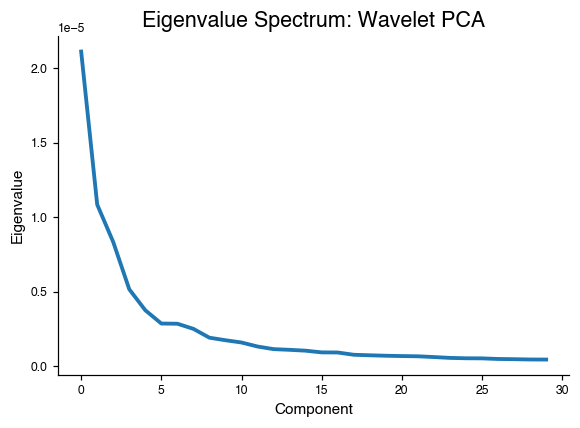

In [7]:
plt.figure(figsize=(6,4))
plt.plot(projection_result['eigvals_pca'],linewidth=2.5)
plt.title('Eigenvalue Spectrum: \
Wavelet PCA',fontsize=14,fontweight="bold")
plt.xlabel('Component',fontsize=10,fontweight="bold")
plt.ylabel('Eigenvalue',fontsize=10,fontweight="bold")
plt.show()

Text(0.5, 1.0, 'PC 1 from wavelets')

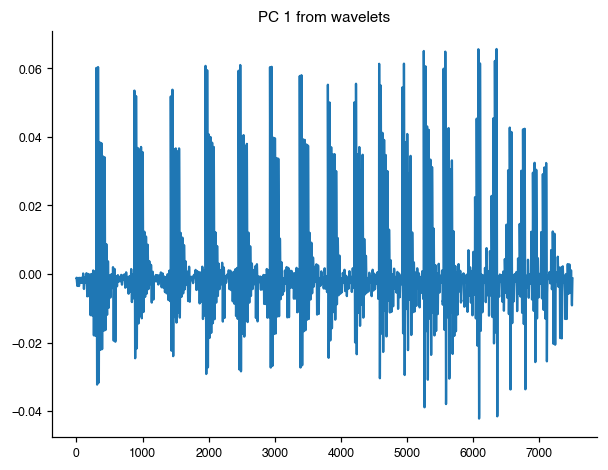

In [8]:
plt.plot(projection_result['pca'].components_[0])
plt.title('PC 1 from wavelets')

In [ ]:
if RUN_CAO_SCAN:
    if projection_result is None:
        raise RuntimeError('Prepare or load projections first.')
    X_tune = pup.projection_sample_for_tuning(proj_files, subsample_factor=20)
    E1 = pp.cao_e1(X_tune, max_d=12, tau=1, n_samples=20000, seed=SEED, verbose=True)
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ax.plot(np.arange(1, len(E1) + 1), E1, 'o-', label="Cao's E1")
    ax.axvline(D_EMBED, color='red', ls='--', label=f'current d={D_EMBED}')
    ax.set_xlabel('embedding dimension d')
    ax.set_ylabel('E1(d)')
    ax.legend()
    if SAVE_TUNING_DIAGNOSTICS:
        fig.savefig(tuning_root / 'cao_embedding_scan.png')
        fig.savefig(tuning_root / 'cao_embedding_scan.pdf')


In [ ]:
if RUN_CLUSTER_SCAN:
    if projection_result is None:
        raise RuntimeError('Prepare or load projections first.')
    N_VALUES = [100,200,250,300,350,400,500]
    N_values, entropy, entropy_shuffled = pup.entropy_gap_pooled_projections(
        proj_files=proj_files,
        d_embed=D_EMBED,
        N_values=N_VALUES,
        lag=max(1, int(TAU_SECONDS * TUNING_FS)),
        framerate=TUNING_FS,
        kmeans_subsample_factor=KMEANS_SUBSAMPLE_FACTOR,
        seed=15,
    )
    entropy_gap = entropy_shuffled - entropy
    cluster_scan = pd.DataFrame({'N': N_values, 'entropy': entropy, 'entropy_shuffled': entropy_shuffled, 'entropy_gap': entropy_gap})
    if SAVE_TUNING_DIAGNOSTICS:
        cluster_scan.to_csv(tuning_root / 'cluster_entropy_scan.csv', index=False)
    display(cluster_scan)
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ax.plot(N_values, entropy_gap, 'o-', label='shuffled - observed entropy')
    ax.axvline(N_CLUSTERS, color='red', ls='--', label=f'current N={N_CLUSTERS}')
    ax.set_xlabel('cluster count N')
    ax.set_ylabel('entropy gap')
    ax.legend()
    if SAVE_TUNING_DIAGNOSTICS:
        fig.savefig(tuning_root / 'cluster_entropy_scan.png')
        fig.savefig(tuning_root / 'cluster_entropy_scan.pdf')


In [ ]:
state_files = sorted((tuning_root / 'states').glob('*_states.npy'))
if RUN_TUNING_STATE_ASSIGNMENT:
    if projection_result is None:
        raise RuntimeError('Prepare or load projections first.')
    state_result = pup.assign_pooled_states_from_projections(
        proj_files=proj_files,
        d_embed=D_EMBED,
        N=N_CLUSTERS,
        output_dir=tuning_root,
        kmeans_subsample_factor=1,
        seed=SEED,
        kmeans_n_init=KMEANS_N_INIT,
    )
    states_list = state_result['states_list']
elif state_files:
    states_list = [np.load(path, mmap_mode='r') for path in state_files]
else:
    print ('turn on tau')

In [ ]:
if RUN_TAU_SCAN:
    if states_list is None:
        raise RuntimeError('Assign or load tuning states first.')
    TAU_VALUES = [0.5, 1, 2, 3,4, 5, 6,7,8,9,10]
    rows = []
    for tau_seconds in TAU_VALUES:
        lag = max(1, int(tau_seconds * TUNING_FS))
        T_tau = pp.make_transition_matrix(states_list, lag=lag, n_states=N_CLUSTERS)
        evals_tau, _ = pp.leading_eigvecs(T_tau, k=10)
        suggested_M, gap, _ = gu.select_M_spectral_gap(evals_tau, M_min=2, M_max=8, warn=False)
        rows.append({'tau_seconds': tau_seconds, 'lag_frames': lag, 'suggested_M': suggested_M, 'spectral_gap_ratio': gap, **{f'lambda_{i + 2}': float(abs(value)) for i, value in enumerate(evals_tau[:6])}})
    tau_scan = pd.DataFrame(rows)
    if SAVE_TUNING_DIAGNOSTICS:
        tau_scan.to_csv(tuning_root / 'tau_slow_mode_scan.csv', index=False)
    display(tau_scan)
    fig, ax = plt.subplots(figsize=(6, 4))
    for index in range(2, 6):
        ax.plot(tau_scan['tau_seconds'], tau_scan[f'lambda_{index}'], 'o-', label=fr'$|\lambda_{index}|$')
    ax.axvline(TAU_SECONDS, color='red', ls='--', label=f'current tau={TAU_SECONDS}s')
    ax.set_xlabel('lag tau (seconds)')
    ax.set_ylabel('eigenvalue magnitude')
    ax.legend()
    if SAVE_TUNING_DIAGNOSTICS:
        fig.savefig(tuning_root / 'tau_slow_mode_scan.png')
        fig.savefig(tuning_root / 'tau_slow_mode_scan.pdf')

In [ ]:
USE_RECURSIVE_ARMS = True
RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT = 20
RECURSIVE_MIN_CHILD_BALANCE = 0.01
RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO = 1.15
RECURSIVE_MIN_CHILD_GLOBAL_PI = 0.02
RECURSIVE_MAX_DEPTH = 4
RECURSIVE_NESTED_BASINS = 2

RUN_CENSORED_SEGMENT_GPCCA = True
CENSORED_GPCCA_CENSOR_ARM = 1
CENSORED_GPCCA_CHI_THRESHOLD = 0.1
CENSORED_GPCCA_N_BASINS = None  # None uses the current N_BASINS.



# # Parameters selected through the tuning section.D_EMBED = 12
N_CLUSTERS = 1000
TAU_SECONDS = 5
N_BASINS = 3
M = 3
D_EMBED = 8


state_files = sorted((tuning_root / 'states').glob('*_states.npy'))
if RUN_TUNING_STATE_ASSIGNMENT:
    if projection_result is None:
        raise RuntimeError('Prepare or load projections first.')
    state_result = pup.assign_pooled_states_from_projections(
        proj_files=proj_files,
        d_embed=D_EMBED,
        N=N_CLUSTERS,
        output_dir=tuning_root,
        kmeans_subsample_factor=1,
        seed=SEED,
        kmeans_n_init=KMEANS_N_INIT,
    )
    states_list = state_result['states_list']
elif state_files:
    states_list = [np.load(path, mmap_mode='r') for path in state_files]
else:
    print ('turn on tau')

if states_list is not None:
    tuning_slow_modes = pup.compute_pooled_slow_modes(
        states_list, fs=TUNING_FS, tau_seconds=TAU_SECONDS,
        N=N_CLUSTERS, M=N_BASINS,
        use_recursive_arms=USE_RECURSIVE_ARMS,
        recursive_min_parent_clusters_to_split=RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT,
        recursive_min_child_balance=RECURSIVE_MIN_CHILD_BALANCE,
        recursive_min_parent_operator_gap_ratio=RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO,
        recursive_min_child_global_pi=RECURSIVE_MIN_CHILD_GLOBAL_PI,
        recursive_max_depth=RECURSIVE_MAX_DEPTH,
        recursive_nested_basins=RECURSIVE_NESTED_BASINS,
    )
    active_gpcca = tuning_slow_modes['gpcca']
    active_M = active_gpcca['chi'].shape[1]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    fg.plot_eigenvalue_dots(axes[0], tuning_slow_modes['evals'], M=active_M)
    axes[0].set_title('slow-mode spectrum')
    # Exclude phi_1, the stationary mode, from the plotted axes.
    phi = np.asarray(tuning_slow_modes['evecs'][:, 1:4].real)
    geometry = gu.compute_hub_arms(phi, tuning_slow_modes['pi'], active_gpcca['chi'])
    axes[1].remove()
    ax3d = fig.add_subplot(1, 2, 2, projection='3d')
    fg.plot_eigenspace_3d(ax3d, phi, pi=tuning_slow_modes['pi'], chi=active_gpcca['chi'], hub=geometry['hub'], arm_dirs=geometry['arm_dirs'], arm_centroids=geometry['arm_centroids'])
    ax3d.set_title(f'recursive leaf-arm projection (M={active_M})')


In [ ]:
gpcca = tuning_slow_modes["gpcca"]
print("active model recursive:", gpcca.get("is_recursive_leaf_gpcca", False))
print("leaf arm count:", gpcca["chi"].shape[1])
print("hard cluster counts:", gpcca["basin_counts"])
print("stationary mass:", gpcca["pi_basin"])
print("mean confidence:", gpcca["chi"].max(axis=1).mean())

base_gpcca = tuning_slow_modes.get("base_gpcca")
if base_gpcca is not None and base_gpcca is not gpcca:
    print("base first-pass hard cluster counts:", base_gpcca["basin_counts"])
    print("base first-pass stationary mass:", base_gpcca["pi_basin"])

arm_tree = tuning_slow_modes.get("arm_tree")
if arm_tree is not None:
    display(arm_tree["node_table"])
    display(arm_tree["cluster_table"].head(30))


## Labmate-style censored-segment GPCCA

This diagnostic follows the labmate workflow exactly: use the original first-pass GPCCA `chi`, censor all microstates whose selected chi arm exceeds `CENSORED_GPCCA_CHI_THRESHOLD`, split the full state time series on those censored frames, rebuild the transfer operator from the remaining contiguous segments, then eigendecompose and run GPCCA on that new operator.


In [ ]:
censored_segment_result = None
if RUN_CENSORED_SEGMENT_GPCCA:
    if states_list is None:
        raise RuntimeError('Assign or load tuning states first.')
    if 'tuning_slow_modes' not in globals():
        raise RuntimeError('Run the slow-mode cell before censored-segment GPCCA.')

    base_gpcca_for_censor = tuning_slow_modes.get('base_gpcca', tuning_slow_modes['gpcca'])
    censored_gpcca_n_basins = (
        N_BASINS if CENSORED_GPCCA_N_BASINS is None
        else int(CENSORED_GPCCA_N_BASINS)
    )
    censored_segment_result = pup.censored_segment_gpcca(
        states_list,
        base_gpcca_for_censor['chi'],
        lag=tuning_slow_modes['lag'],
        n_states=N_CLUSTERS,
        M=censored_gpcca_n_basins,
        censor_arm=CENSORED_GPCCA_CENSOR_ARM,
        chi_threshold=CENSORED_GPCCA_CHI_THRESHOLD,
        store_original_indices=False,
    )

    censored_root = tuning_root / 'censored_segment_gpcca'
    censored_root.mkdir(parents=True, exist_ok=True)
    censored_segment_result['segment_table'].to_csv(
        censored_root / 'censored_segment_table.csv', index=False,
    )
    cluster_table = pd.DataFrame({
        'original_cluster': censored_segment_result['local_to_original'],
        'censored_local_cluster': np.arange(censored_segment_result['n_states']),
        'censored_gpcca_arm': censored_segment_result['assignments'],
        'censored_pi': censored_segment_result['pi'],
        'base_censor_chi': base_gpcca_for_censor['chi'][
            censored_segment_result['local_to_original'],
            CENSORED_GPCCA_CENSOR_ARM,
        ],
    })
    for arm in range(censored_segment_result['chi'].shape[1]):
        cluster_table[f'censored_chi_{arm + 1}'] = censored_segment_result['chi'][:, arm]
    cluster_table.to_csv(censored_root / 'censored_cluster_assignments.csv', index=False)
    np.save(censored_root / 'censored_transfer_operator.npy', censored_segment_result['T'])
    np.save(censored_root / 'censored_stationary_distribution.npy', censored_segment_result['pi'])
    np.save(censored_root / 'censored_evals.npy', censored_segment_result['evals'])
    np.save(censored_root / 'censored_evecs.npy', censored_segment_result['evecs'])
    np.save(censored_root / 'censored_chi.npy', censored_segment_result['chi'])

    summary = pd.DataFrame([{
        'censor_arm': CENSORED_GPCCA_CENSOR_ARM,
        'chi_threshold': CENSORED_GPCCA_CHI_THRESHOLD,
        'censored_original_clusters': len(censored_segment_result['censor_clusters']),
        'uncensored_original_clusters': len(censored_segment_result['keep_clusters']),
        'n_segments': censored_segment_result['n_segments'],
        'n_usable_segments': censored_segment_result['n_usable_segments'],
        'n_segment_frames': censored_segment_result['n_segment_frames'],
        'n_usable_segment_frames': censored_segment_result['n_usable_segment_frames'],
        'lag_frames': censored_segment_result['lag'],
        'M': censored_gpcca_n_basins,
        'gpcca_crispness': censored_segment_result['gpcca']['crispness'],
        'basin_counts': censored_segment_result['gpcca']['basin_counts'].tolist(),
        'pi_basin': censored_segment_result['gpcca']['pi_basin'].round(6).tolist(),
    }])
    summary.to_csv(censored_root / 'censored_segment_summary.csv', index=False)
    display(summary)
    display(cluster_table.sort_values(['censored_gpcca_arm', 'censored_pi'], ascending=[True, False]).head(40))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    fg.plot_eigenvalue_dots(
        axes[0], censored_segment_result['evals'], M=censored_gpcca_n_basins,
    )
    axes[0].set_title('censored-segment spectrum')
    axes[1].bar(
        np.arange(censored_gpcca_n_basins),
        censored_segment_result['gpcca']['pi_basin'],
    )
    axes[1].set_xlabel('censored GPCCA arm')
    axes[1].set_ylabel('stationary mass')
    axes[1].set_title('censored-segment arm mass')
    fig.savefig(censored_root / 'censored_segment_spectrum_and_mass.png', dpi=260)
    display(fig)
    plt.close(fig)

    fig = plt.figure(figsize=(6.4, 5.2), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    fg.plot_eigenspace_3d(
        ax,
        censored_segment_result['phi'],
        pi=censored_segment_result['pi'],
        chi=censored_segment_result['chi'],
        hub=censored_segment_result['geometry']['hub'],
        arm_dirs=censored_segment_result['geometry']['arm_dirs'],
        arm_centroids=censored_segment_result['geometry']['arm_centroids'],
    )
    ax.set_title(
        f'censored-segment GPCCA: censor arm {CENSORED_GPCCA_CENSOR_ARM}, chi>{CENSORED_GPCCA_CHI_THRESHOLD}'
    )
    fig.savefig(censored_root / 'censored_segment_arm_projection.png', dpi=260)
    display(fig)
    plt.close(fig)

    fig, ax, censored_order = pup.plot_clustered_transfer_operator(
        censored_segment_result['T'],
        pi=censored_segment_result['pi'],
        title='censored-segment transfer operator',
        output_prefix=censored_root / 'censored_segment_transfer_operator',
    )
    display(fig)
    plt.close(fig)


In [ ]:
gpcca = tuning_slow_modes["gpcca"]
assignments = gpcca["assignments"]
pi = tuning_slow_modes["pi"]
T = tuning_slow_modes["T"]

for basin in range(gpcca["chi"].shape[1]):
    members = np.flatnonzero(assignments == basin)
    print(
        f"basin {basin}:",
        "clusters", members,
        "pi", pi[members],
        "self-transition", np.diag(T)[members],
    )

In [ ]:
for basin in range(4):
    members = np.flatnonzero(assignments == basin)
    fractions = [
        np.mean(np.isin(states, members))
        for states in states_list
    ]
    print(f"basin {basin} per-individual occupancy:", fractions)

In [ ]:
for cluster in [272, 109]:
    print(f"\ncluster {cluster}")
    for individual_id, states in zip(tuning_ids, states_list):
        fraction = np.mean(states == cluster)
        if fraction > 0:
            print(individual_id, fraction)

## 4. Leave-one-fly-out validation of basin count

For each candidate number of basins and each held-out fly, G-PCCA is re-fit using only the remaining flies. Orange circles show held-out basin-level lagged mutual information; gray squares show the mean of matched-size random cluster colorings.


In [ ]:
FIXED_BASIN_VALIDATION_M = 3
M = 3

In [ ]:
basin_validation = None


if RUN_BASIN_COUNT_VALIDATION_SWEEP:
    if states_list is None:
        raise RuntimeError('Assign or load tuning states first.')
    if len(states_list) < 2:
        raise RuntimeError('Leave-one-fly-out validation needs at least two flies.')

    validation_root = tuning_root / 'leave_one_fly_out_basin_count_sweep'
    validation_root.mkdir(parents=True, exist_ok=True)
    validation_ids = (
        tuning_ids if len(tuning_ids) == len(states_list)
        else [path.stem.removesuffix('_states') for path in state_files]
    )
    basin_validation = pup.leave_one_individual_out_basin_validation(
        states_list,
        lag=max(1, int(TAU_SECONDS * TUNING_FS)),
        n_states=N_CLUSTERS,
        M_values=BASIN_VALIDATION_M_VALUES,
        n_random=BASIN_VALIDATION_N_RANDOM,
        seed=SEED,
        individual_ids=validation_ids,
    )
    basin_validation['folds'].to_csv(
        validation_root / 'leave_one_fly_out_folds.csv', index=False,
    )
    basin_validation['summary'].to_csv(
        validation_root / 'leave_one_fly_out_summary.csv', index=False,
    )
    validation_title = (
        f'{TUNING_SPECIES}: leave-one-fly-out basin validation '
        f'(N={N_CLUSTERS}, tau={TAU_SECONDS:g}s, '
        f'{BASIN_VALIDATION_N_RANDOM} random colorings/fold)'
    )
    fig, ax = pup.plot_leave_one_individual_out_basin_validation(
        basin_validation['folds'],
        title=validation_title,
        output_prefix=validation_root / 'leave_one_fly_out_basin_mi',
    )
    ax.axvline(
        N_BASINS, color='#2F5597', linestyle='--', linewidth=1.2,
        label=f'current M={N_BASINS}',
    )
    ax.legend(frameon=False)
    fig.savefig(validation_root / 'leave_one_fly_out_basin_mi.png', dpi=260)
    fig.savefig(validation_root / 'leave_one_fly_out_basin_mi.pdf')
    display(fig)
    plt.close(fig)
    display(basin_validation['summary'])


fixed_basin_validation = None
if RUN_FIXED_M_LEAVE_ONE_FLY_OUT_VALIDATION:
    if states_list is None:
        raise RuntimeError('Assign or load tuning states first.')
    if len(states_list) < 2:
        raise RuntimeError('Leave-one-fly-out validation needs at least two flies.')

    fixed_validation_root = tuning_root / 'leave_one_fly_out_fixed_M'
    fixed_validation_root.mkdir(parents=True, exist_ok=True)
    fixed_validation_ids = (
        tuning_ids if len(tuning_ids) == len(states_list)
        else [path.stem.removesuffix('_states') for path in state_files]
    )
    fixed_basin_validation = pup.leave_one_individual_out_basin_validation(
        states_list,
        lag=max(1, int(TAU_SECONDS * TUNING_FS)),
        n_states=N_CLUSTERS,
        M_values=[FIXED_BASIN_VALIDATION_M],
        n_random=BASIN_VALIDATION_N_RANDOM,
        seed=SEED,
        individual_ids=fixed_validation_ids,
    )
    fixed_M_folds = fixed_basin_validation['folds']
    fixed_M_title = (
        f'{TUNING_SPECIES}: leave-one-fly-out validation at '
        f'M={FIXED_BASIN_VALIDATION_M} (N={N_CLUSTERS}, '
        f'tau={TAU_SECONDS:g}s)'
    )
    fixed_M_prefix = fixed_validation_root / (
        f'leave_one_fly_out_fixed_M{FIXED_BASIN_VALIDATION_M}'
    )
    fig, ax = pup.plot_fixed_M_leave_one_individual_out_validation(
        fixed_M_folds,
        M=FIXED_BASIN_VALIDATION_M,
        title=fixed_M_title,
        output_prefix=fixed_M_prefix,
    )
    display(fig)
    plt.close(fig)
    fixed_M_folds.to_csv(
        fixed_validation_root / f'leave_one_fly_out_fixed_M{FIXED_BASIN_VALIDATION_M}.csv',
        index=False,
    )
    display(fixed_M_folds)


## 5. Parameter sweep arm plots

Sweep selected tuning parameter combinations and display/save an arm/eigenspace plot for each combination. Plot titles include the parameters used for that run.


In [ ]:
PARAMETER_SWEEP_COMBINATIONS

In [ ]:
sweep_rows = []
if RUN_PARAMETER_SWEEP:
    if projection_result is None:
        raise RuntimeError('Prepare or load projections first.')

    for index, params in enumerate(PARAMETER_SWEEP_COMBINATIONS, start=1):
        d_embed = int(params.get('d_embed', D_EMBED))
        n_clusters = int(params.get('N', params.get('n_clusters', N_CLUSTERS)))
        tau_seconds = float(params.get('tau_seconds', TAU_SECONDS))
        n_basins = int(params.get('M', params.get('n_basins', N_BASINS)))
        kmeans_subsample = int(params.get('kmeans_subsample_factor', KMEANS_SUBSAMPLE_FACTOR))
        seed = int(params.get('seed', SEED))

        label = (
            f'd{d_embed}_N{n_clusters}_'
            f'tau{str(tau_seconds).replace(".", "p")}s_M{n_basins}_'
            f'kmSub{kmeans_subsample}_seed{seed}'
        )
        print(f'[{index}/{len(PARAMETER_SWEEP_COMBINATIONS)}] {label}')
        combo_state_result = pup.assign_pooled_states_from_projections(
            proj_files=proj_files,
            d_embed=d_embed,
            N=n_clusters,
            output_dir=tuning_root,
            save_states=False,
            kmeans_subsample_factor=kmeans_subsample,
            seed=seed,
            kmeans_n_init=KMEANS_N_INIT,
        )
        combo_states = combo_state_result['states_list']

        combo_slow_modes = pup.compute_pooled_slow_modes(
            combo_states,
            fs=TUNING_FS,
            tau_seconds=tau_seconds,
            N=n_clusters,
            M=n_basins,
            use_recursive_arms=USE_RECURSIVE_ARMS,
            recursive_min_parent_clusters_to_split=RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT,
            recursive_min_child_balance=RECURSIVE_MIN_CHILD_BALANCE,
            recursive_min_parent_operator_gap_ratio=RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO,
            recursive_min_child_global_pi=RECURSIVE_MIN_CHILD_GLOBAL_PI,
            recursive_max_depth=RECURSIVE_MAX_DEPTH,
            recursive_nested_basins=RECURSIVE_NESTED_BASINS,
        )

        phi = np.asarray(combo_slow_modes['evecs'][:, 1:4].real)
        if phi.shape[1] < 3:
            phi = np.pad(phi, ((0, 0), (0, 3 - phi.shape[1])))
        geometry = gu.compute_hub_arms(
            phi,
            combo_slow_modes['pi'],
            combo_slow_modes['gpcca']['chi'],
        )

        title = (
            f'{TUNING_SPECIES}: d={d_embed}, N={n_clusters}, '
            f'tau={tau_seconds:g}s, M={n_basins}, '
            f'kmeans_subsample={kmeans_subsample}, seed={seed}'
        )
        fig = plt.figure(figsize=(6.4, 5.2), constrained_layout=True)
        ax = fig.add_subplot(111, projection='3d')
        fg.plot_eigenspace_3d(
            ax,
            phi,
            pi=combo_slow_modes['pi'],
            chi=combo_slow_modes['gpcca']['chi'],
            hub=geometry['hub'],
            arm_dirs=geometry['arm_dirs'],
            arm_centroids=geometry['arm_centroids'],
        )
        ax.set_title(title, pad=18)
        display(fig)
        plt.close(fig)

        sweep_rows.append({
            'label': label,
            'd_embed': d_embed,
            'N': n_clusters,
            'tau_seconds': tau_seconds,
            'M': n_basins,
            'leaf_arms': combo_slow_modes['gpcca']['chi'].shape[1],
            'kmeans_subsample_factor': kmeans_subsample,
            'seed': seed,
            'lag_frames': combo_slow_modes['lag'],
        })

if sweep_rows:
    display(pd.DataFrame(sweep_rows))


## 6. Clustered transfer operator and low-occupancy coarse-graining

Visualize the transfer operator, then merge barely visited clusters into their nearest retained transition-profile neighbor and visualize the coarse-grained operator.


In [ ]:
COARSE_GRAIN_MIN_PI = 10e-4

In [ ]:
coarse_grain_result = None
if RUN_TRANSFER_OPERATOR_COARSE_GRAIN:
    if states_list is None:
        raise RuntimeError('Assign or load tuning states first.')

    if 'tuning_slow_modes' not in globals():
        tuning_slow_modes = pup.compute_pooled_slow_modes(
            states_list,
            fs=TUNING_FS,
            tau_seconds=TAU_SECONDS,
            N=N_CLUSTERS,
            M=N_BASINS,
            use_recursive_arms=USE_RECURSIVE_ARMS,
            recursive_min_parent_clusters_to_split=RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT,
            recursive_min_child_balance=RECURSIVE_MIN_CHILD_BALANCE,
            recursive_min_parent_operator_gap_ratio=RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO,
            recursive_min_child_global_pi=RECURSIVE_MIN_CHILD_GLOBAL_PI,
            recursive_max_depth=RECURSIVE_MAX_DEPTH,
            recursive_nested_basins=RECURSIVE_NESTED_BASINS,
        )

    coarse_root = tuning_root / 'transfer_operator_coarse_grain'
    coarse_root.mkdir(parents=True, exist_ok=True)

    transfer_title = (
        f'{TUNING_SPECIES}: clustered transfer operator '
        f'(d={D_EMBED}, N={N_CLUSTERS}, tau={TAU_SECONDS:g}s)'
    )
    fig, ax, clustered_order = pup.plot_clustered_transfer_operator(
        tuning_slow_modes['T'],
        pi=tuning_slow_modes['pi'],
        title=transfer_title,
        output_prefix=coarse_root / 'clustered_transfer_operator',
    )
    display(fig)
    plt.close(fig)

    coarse_grain_result = pup.coarse_grain_low_occupancy_clusters(
        tuning_slow_modes['T'],
        tuning_slow_modes['pi'],
        min_pi=COARSE_GRAIN_MIN_PI,
    )
    coarse_grain_result['merge_table'].to_csv(coarse_root / 'low_occupancy_cluster_merges.csv', index=False)
    coarse_grain_result['map_table'].to_csv(coarse_root / 'cluster_to_coarse_cluster_map.csv', index=False)
    np.save(coarse_root / 'coarse_grained_transfer_operator.npy', coarse_grain_result['T'])
    np.save(coarse_root / 'coarse_grained_stationary_distribution.npy', coarse_grain_result['pi'])

    coarse_title = (
        f'{TUNING_SPECIES}: coarse-grained transfer operator '
        f'(min pi={COARSE_GRAIN_MIN_PI:g}; '
        f'{len(coarse_grain_result["merge_table"])} merged)'
    )
    fig, ax, coarse_order = pup.plot_clustered_transfer_operator(
        coarse_grain_result['T'],
        pi=coarse_grain_result['pi'],
        title=coarse_title,
        output_prefix=coarse_root / 'coarse_grained_clustered_transfer_operator',
    )
    display(fig)
    plt.close(fig)

    coarse_evals, coarse_evecs = pp.leading_eigvecs(coarse_grain_result['T'], k=10)
    coarse_gpcca = gu.run_gpcca(
        coarse_grain_result['T'],
        M=min(N_BASINS, coarse_grain_result['T'].shape[0]),
        eta=coarse_grain_result['pi'],
    )
    np.save(coarse_root / 'coarse_grained_evals.npy', coarse_evals)
    np.save(coarse_root / 'coarse_grained_evecs.npy', coarse_evecs)
    np.save(coarse_root / 'coarse_grained_chi.npy', coarse_gpcca['chi'])

    coarse_phi = np.asarray(coarse_evecs[:, 1:4].real)
    if coarse_phi.shape[1] < 3:
        coarse_phi = np.pad(coarse_phi, ((0, 0), (0, 3 - coarse_phi.shape[1])))
    coarse_geometry = gu.compute_hub_arms(
        coarse_phi,
        coarse_grain_result['pi'],
        coarse_gpcca['chi'],
    )
    coarse_arm_title = (
        f'{TUNING_SPECIES}: coarse-grained arms '
        f'(min pi={COARSE_GRAIN_MIN_PI:g}; '
        f'N={coarse_grain_result["T"].shape[0]}, M={coarse_gpcca["chi"].shape[1]})'
    )
    fig = plt.figure(figsize=(6.4, 5.2), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    fg.plot_eigenspace_3d(
        ax,
        coarse_phi,
        pi=coarse_grain_result['pi'],
        chi=coarse_gpcca['chi'],
        hub=coarse_geometry['hub'],
        arm_dirs=coarse_geometry['arm_dirs'],
        arm_centroids=coarse_geometry['arm_centroids'],
    )
    ax.set_title(coarse_arm_title, pad=18)
    coarse_arm_png = coarse_root / 'coarse_grained_arm_plot.png'
    coarse_arm_pdf = coarse_root / 'coarse_grained_arm_plot.pdf'
    fig.savefig(coarse_arm_png, dpi=260, bbox_inches='tight')
    fig.savefig(coarse_arm_pdf, bbox_inches='tight')
    display(fig)
    plt.close(fig)

    summary = pd.DataFrame([{
        'min_pi': COARSE_GRAIN_MIN_PI,
        'original_clusters': tuning_slow_modes['T'].shape[0],
        'coarse_clusters': coarse_grain_result['T'].shape[0],
        'merged_clusters': len(coarse_grain_result['merge_table']),
        'clustered_transfer_operator_png': str(coarse_root / 'clustered_transfer_operator.png'),
        'coarse_grained_transfer_operator_png': str(coarse_root / 'coarse_grained_clustered_transfer_operator.png'),
        'coarse_grained_arm_plot_png': str(coarse_arm_png),
        'merge_table_csv': str(coarse_root / 'low_occupancy_cluster_merges.csv'),
        'map_table_csv': str(coarse_root / 'cluster_to_coarse_cluster_map.csv'),
    }])
    summary.to_csv(coarse_root / 'coarse_grain_summary.csv', index=False)
    display(summary)
    if len(coarse_grain_result['merge_table']):
        display(coarse_grain_result['merge_table'].sort_values('pi').head(20))


## 7. Final single-species and batch runs

In [ ]:
single_species_results = {}
if RUN_SINGLE_SPECIES_FINAL:
    for representation, loader in LOADERS.items():
        run_root = OUTPUT_ROOT / representation
        single_species_results[representation] = pup.run_species_batch(
            species_names=[TUNING_SPECIES],
            species_subjects_fn=distance_data.species_subjects,
            select_manifest_fn=distance_data.select_manifest,
            samplerate_fn=distance_data.samplerate,
            load_individual_trace_fn=loader,
            dataset_name=representation,
            stride=STRIDE,
            max_frames_per_recording=MAX_FRAMES_PER_RECORDING,
            n_freqs=N_FREQS, d_embed=D_EMBED, N=N_CLUSTERS,
            tau_seconds=TAU_SECONDS, M=N_BASINS,
            output_root=run_root,
            random_n_individuals=TUNING_N_INDIVIDUALS,
            seed=SEED,
            wavelet_subsample_factor=WAVELET_SUBSAMPLE_FACTOR,
            kmeans_subsample_factor=KMEANS_SUBSAMPLE_FACTOR,
            pca_max_components=PCA_MAX_COMPONENTS,
            n_shuffles=N_SHUFFLES,
            normalize_wavelets_for_pca=NORMALIZE_WAVELETS_FOR_PCA,
            kmeans_n_init=KMEANS_N_INIT,
            assignment_chunk_rows=ASSIGNMENT_CHUNK_ROWS,
            use_recursive_arms=USE_RECURSIVE_ARMS,
            recursive_min_parent_clusters_to_split=RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT,
            recursive_min_child_balance=RECURSIVE_MIN_CHILD_BALANCE,
            recursive_min_parent_operator_gap_ratio=RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO,
            recursive_min_child_global_pi=RECURSIVE_MIN_CHILD_GLOBAL_PI,
            recursive_max_depth=RECURSIVE_MAX_DEPTH,
            recursive_nested_basins=RECURSIVE_NESTED_BASINS,
            fmin=FMIN, fmax_cap=FMAX_CAP,
        )
        display(single_species_results[representation])


In [ ]:
batch_results = {}
if RUN_BATCH:
    for representation, loader in LOADERS.items():
        run_root = OUTPUT_ROOT / representation
        print(f'\n=== Batch: {representation} ===')
        batch_results[representation] = pup.run_species_batch(
            species_names=BATCH_SPECIES,
            species_subjects_fn=distance_data.species_subjects,
            select_manifest_fn=distance_data.select_manifest,
            samplerate_fn=distance_data.samplerate,
            load_individual_trace_fn=loader,
            dataset_name=representation,
            stride=STRIDE,
            max_frames_per_recording=MAX_FRAMES_PER_RECORDING,
            n_freqs=N_FREQS, d_embed=D_EMBED, N=N_CLUSTERS,
            tau_seconds=TAU_SECONDS, M=N_BASINS,
            output_root=run_root,
            random_n_individuals=BATCH_N_INDIVIDUALS,
            seed=SEED,
            wavelet_subsample_factor=WAVELET_SUBSAMPLE_FACTOR,
            kmeans_subsample_factor=KMEANS_SUBSAMPLE_FACTOR,
            pca_max_components=PCA_MAX_COMPONENTS,
            n_shuffles=N_SHUFFLES,
            normalize_wavelets_for_pca=NORMALIZE_WAVELETS_FOR_PCA,
            kmeans_n_init=KMEANS_N_INIT,
            assignment_chunk_rows=ASSIGNMENT_CHUNK_ROWS,
            use_recursive_arms=USE_RECURSIVE_ARMS,
            recursive_min_parent_clusters_to_split=RECURSIVE_MIN_PARENT_CLUSTERS_TO_SPLIT,
            recursive_min_child_balance=RECURSIVE_MIN_CHILD_BALANCE,
            recursive_min_parent_operator_gap_ratio=RECURSIVE_MIN_PARENT_OPERATOR_GAP_RATIO,
            recursive_min_child_global_pi=RECURSIVE_MIN_CHILD_GLOBAL_PI,
            recursive_max_depth=RECURSIVE_MAX_DEPTH,
            recursive_nested_basins=RECURSIVE_NESTED_BASINS,
            fmin=FMIN, fmax_cap=FMAX_CAP,
        )
        display(batch_results[representation])
        gc.collect()


## 8. Multispecies slow-mode, arm, transfer, and MoSeq analysis

For every representation this produces species eigenspace/arm projections, basin occupancy and persistence, native and behavior-aligned transfer matrices, MoSeq syllable profiles per basin, pairwise comparisons, and cluster summaries.

In [ ]:
required_saved_files = ['chi.npy', 'stationary_distribution.npy', 'transfer_operator.npy', 'evals.npy', 'evecs.npy', 'frame_cluster_assignments.csv']
saved_run_rows = []
for representation in REPRESENTATIONS:
    run_root = OUTPUT_ROOT / representation
    for species in BATCH_SPECIES:
        final_dir = run_root / species / 'final_outputs'
        missing = [name for name in required_saved_files if not (final_dir / name).exists()]
        saved_run_rows.append({'representation': representation, 'species': species, 'complete': not missing, 'missing': '; '.join(missing), 'final_dir': str(final_dir)})
saved_run_validation = pd.DataFrame(saved_run_rows)
display(saved_run_validation)


In [ ]:
multispecies_results = {}
if RUN_MULTISPECIES_ANALYSIS:
    incomplete = saved_run_validation[~saved_run_validation['complete']]
    if not incomplete.empty:
        raise FileNotFoundError('Complete the batch runs first:\n' + incomplete.to_string(index=False))
    for representation in REPRESENTATIONS:
        run_root = OUTPUT_ROOT / representation
        multispecies_results[representation] = msc.run_multi_species_comparisons(
            batch_root=run_root,
            species=BATCH_SPECIES,
            reference_species=REFERENCE_SPECIES,
            moseq_timeseries_csv=MOSEQ_TIMESERIES_CSV,
            output_dir=run_root / 'basin_species_comparisons',
            syllable_name_candidates=SYLLABLE_NAME_CANDIDATES,
        )
        display(multispecies_results[representation]['moseq_profile_stats'])
        display(multispecies_results[representation]['pairwise_species_comparison'])


## 9. Review saved analyses and compare representations

In [ ]:
analysis_tables = {}
for representation in REPRESENTATIONS:
    comparison_dir = OUTPUT_ROOT / representation / 'basin_species_comparisons'
    if not comparison_dir.exists():
        continue
    analysis_tables[representation] = {
        'transfer': pd.read_csv(comparison_dir / 'cluster_transfer_summaries.csv'),
        'basins': pd.read_csv(comparison_dir / 'basin_summaries.csv'),
        'moseq_join': pd.read_csv(comparison_dir / 'moseq_profile_join_stats.csv'),
        'top_syllables': pd.read_csv(comparison_dir / 'compact_top_moseq_syllables_by_basin.csv'),
        'pairwise': pd.read_csv(comparison_dir / 'pairwise_behavior_aligned_species_comparison.csv'),
    }

for representation, tables in analysis_tables.items():
    print(f'\n{representation}')
    display(tables['moseq_join'])
    display(tables['top_syllables'])
    display(tables['pairwise'].sort_values(['mean_matched_behavior_similarity', 'basin_transfer_frobenius_distance'], ascending=[False, True]))

if len(analysis_tables) > 1:
    representation_pairwise = pd.concat([
        tables['pairwise'].assign(representation=representation)
        for representation, tables in analysis_tables.items()
    ], ignore_index=True)
    display(representation_pairwise.sort_values(['species_a', 'species_b', 'representation']))


## 10. Output index

In [ ]:
output_rows = []
for representation in REPRESENTATIONS:
    run_root = OUTPUT_ROOT / representation
    comparison_dir = run_root / 'basin_species_comparisons'
    output_rows.append({
        'representation': representation,
        'batch_root': str(run_root),
        'batch_summary_exists': (run_root / 'batch_summary.csv').exists(),
        'comparison_tables': len(list(comparison_dir.glob('*.csv'))) if comparison_dir.exists() else 0,
        'comparison_png_plots': len(list((comparison_dir / 'plots').glob('*.png'))) if comparison_dir.exists() else 0,
        'comparison_pdf_plots': len(list((comparison_dir / 'plots').glob('*.pdf'))) if comparison_dir.exists() else 0,
    })
display(pd.DataFrame(output_rows))


In [ ]:
proj_files = projection_result["proj_files"]

In [ ]:
state_result = pup.assign_pooled_states_from_projections(
    proj_files=proj_files,
    d_embed=D_EMBED,
    N=N_CLUSTERS,
    output_dir=tuning_root,
    kmeans_subsample_factor=KMEANS_SUBSAMPLE_FACTOR,
    seed=SEED,
    kmeans_n_init=KMEANS_N_INIT,
    assignment_chunk_rows=ASSIGNMENT_CHUNK_ROWS,
)

states_list = state_result["states_list"]